<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module4_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)

In [25]:
def eval_5th_degree(coeffs, x):
    return (coeffs[0]*x**5 +
            coeffs[1]*x**4 +
            coeffs[2]*x**3 +
            coeffs[3]*x**2 +
            coeffs[4]*x +
            coeffs[5])
    """
    Function to return the output of evaluating a second degree polynomial,
    given a specific x value.

    Args:
        coeffs: List containing the coefficients a, b, and c for the polynomial.
        x: The input x value to the polynomial.

    Returns:
        y: The corresponding output y value for the second degree polynomial.

    """

    a = coeffs[0] * (x * x)
    b = coeffs[1] * x
    c = coeffs[2]
    y = a + b + c
    return y

hundred_xs = np.random.uniform(-10, 10, 100)
coeffs = [1, 2, -3, 4, 5, 6]

xs = []
ys = []
for x in hundred_xs:
    y  = eval_5th_degree(coeffs, x)
    xs.append(x)
    ys.append(y)

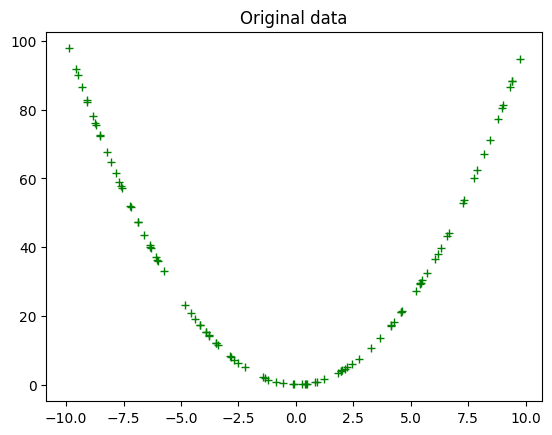

In [3]:
plt.plot(xs, ys, 'g+')
plt.title('Original data')
plt.show()

In [26]:
def eval_5th_degree_jitter(coeffs, x, j):
    """
    Function to return the noisy output of evaluating a fifth degree polynomial,
    given a specific x value. Output values can be within [y − j, y + j].

    Args:
        coeffs: List containing the coefficients a, b, and c for the polynomial.
        x: The input x value to the polynomial.
        j: Jitter parameter, to introduce noise to output y.

    Returns:
        y: The corresponding jittered output y value for the second degree polynomial.

    """

    a = coeffs[0] * (x * x)
    b = coeffs[1] * x
    c = coeffs[2]
    y = a + b + c

    interval = [y - j, y + j]
    interval_min = interval[0]
    interval_max = interval[1]
    jit_val = random.random() * interval_max      # Generate a random number in range 0 to interval max

    while interval_min > jit_val:                 # While the random jitter value is less than the interval min,
        jit_val = random.random() * interval_max  # it is not in the right range. Re-roll the generator until it
                                                  # give a number greater than the interval min.

    return jit_val

xs = []
ys = []
for x in hundred_xs:
    y  = eval_5th_degree_jitter(coeffs, x, 0.1)
    xs.append(x)
    ys.append(y)


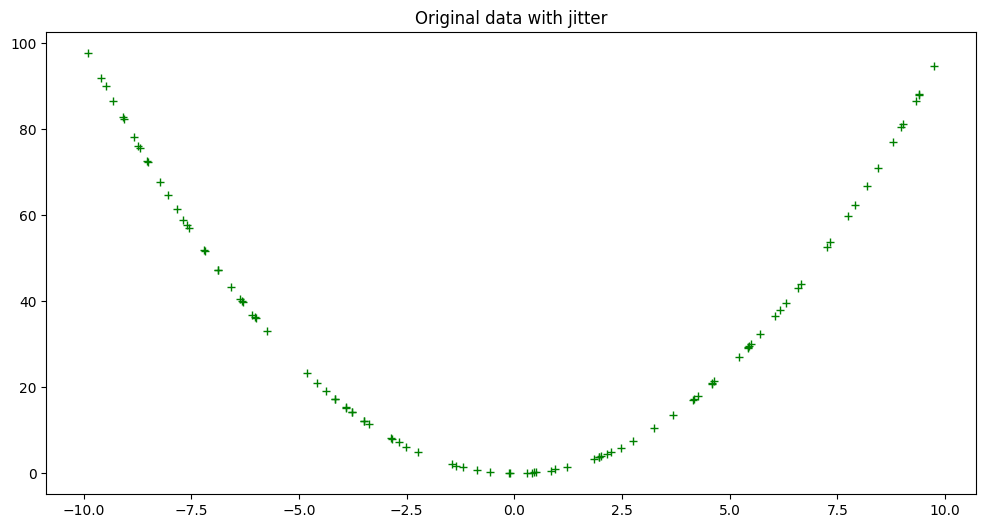

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+')
plt.title('Original data with jitter')
plt.show()

In [6]:
def loss_mse(ys, y_bar):
    """
    Calculates MSE loss.

    Args:
        ys: training data labels
        y_bar: prediction labels

    Returns: Calculated MSE loss.
    """

    return sum((ys - y_bar) * (ys - y_bar)) / len(ys)

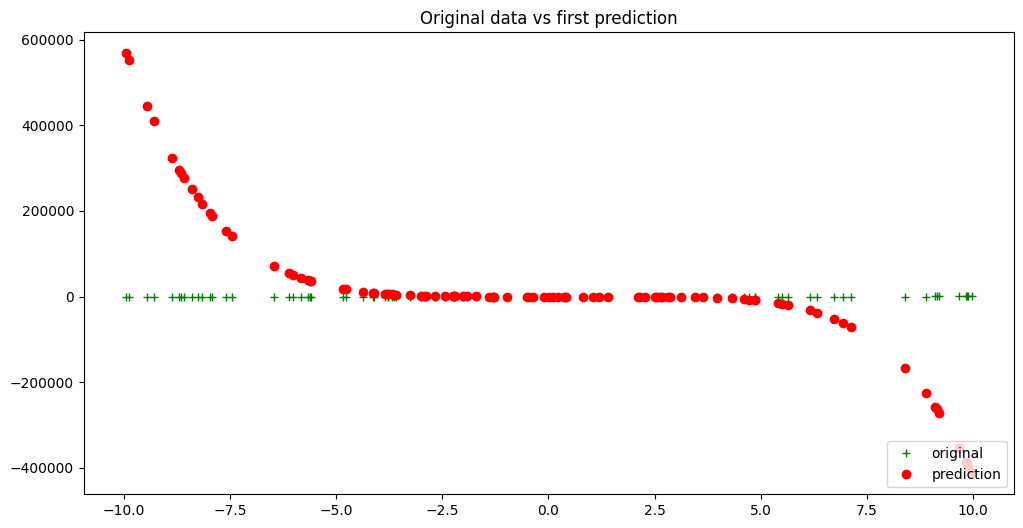

In [30]:
# Pick random coefficients for our initial model
rand_coeffs = (
    random.randrange(-10,10),
    random.randrange(-10,10),
    random.randrange(-10,10),
    random.randrange(-10,10),
    random.randrange(-10,10),
    random.randrange(-10,10)
)

# Get the model's predictions
y_bar = eval_5th_degree(rand_coeffs, hundred_xs)

# Plot the original data vs. our random model's prediction
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, y_bar, 'ro', label = 'prediction')
plt.title('Original data vs first prediction')
plt.legend(loc="lower right")
plt.show()

In [32]:
initial_model_loss = loss_mse(ys, y_bar)
initial_model_loss

np.float64(27037341544.77939)

In [53]:
def calc_gradient_5th_poly(coeffs, inputs_x, outputs_y):
    """
    Calculates gradients for a 5th degree polynomial:

    y = ax^5 + bx^4 + cx^3 + dx^2 + ex + f
    """

    a_s = []
    b_s = []
    c_s = []
    d_s = []
    e_s = []
    f_s = []

    y_bars = eval_5th_degree(coeffs, inputs_x)

    for x, y, y_bar in zip(inputs_x, outputs_y, y_bars):

        error = y - y_bar

        a_s.append((x**5) * error)
        b_s.append((x**4) * error)
        c_s.append((x**3) * error)
        d_s.append((x**2) * error)
        e_s.append(x * error)
        f_s.append(error)

    n = len(y_bars)

    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)
    gradient_d = (-2 / n) * sum(d_s)
    gradient_e = (-2 / n) * sum(e_s)
    gradient_f = (-2 / n) * sum(f_s)

    return (
        gradient_a,
        gradient_b,
        gradient_c,
        gradient_d,
        gradient_e,
        gradient_f
    )   # return calculated gradients as a a tuple of its 3 parts

In [54]:
print(rand_coeffs)
print(len(rand_coeffs))
print(calc_grad)
print(len(calc_grad))

(-5, 8, 0, 9, 9, 0)
6
(np.float64(1580482.1643262731), np.float64(-1499558.0933795976), np.float64(29806.39437765734))
3


In [37]:
print(rand_coeffs)

(-5, 8, 0, 9, 9, 0)


In [55]:
# Calculate the gradients for our random model
calc_grad = calc_gradient_5th_poly(rand_coeffs, hundred_xs, ys)

# Define a learning rate
lr = 0.0001

# Update the coefficients
a_new = rand_coeffs[0] - lr * calc_grad[0]
b_new = rand_coeffs[1] - lr * calc_grad[1]
c_new = rand_coeffs[2] - lr * calc_grad[2]
d_new = rand_coeffs[3] - lr * calc_grad[3]
e_new = rand_coeffs[4] - lr * calc_grad[4]
f_new = rand_coeffs[5] - lr * calc_grad[5]

new_model_coeffs = (
    a_new,
    b_new,
    c_new,
    d_new,
    e_new,
    f_new
)

print(f"New model coeffs: {new_model_coeffs}")

# Get predictions with the new coefficients
new_y_bar = eval_5th_degree(new_model_coeffs, hundred_xs)
updated_model_loss = loss_mse(ys, new_y_bar)

print(f"Now have smaller model loss: {updated_model_loss} vs {initial_model_loss}")

New model coeffs: (np.float64(1069280.1581997215), np.float64(-7594.3769919971855), np.float64(12402.907921269327), np.float64(-149.04821643262733), np.float64(158.95580933795978), np.float64(-2.980639437765734))
Now have smaller model loss: 1.2463494458633345e+21 vs 27037341544.77939


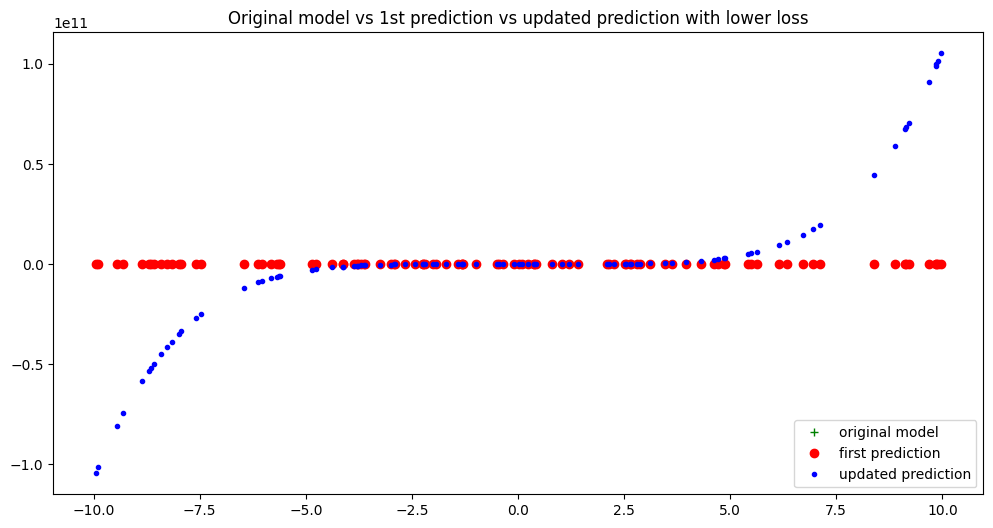

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original model')
plt.plot(xs, y_bar, 'ro', label = 'first prediction')
plt.plot(xs, new_y_bar, 'b.', label = 'updated prediction')
plt.title('Original model vs 1st prediction vs updated prediction with lower loss')
plt.legend(loc="lower right")
plt.show()

In [57]:
def calc_gradient_5th_poly_for_GD(coeffs, inputs_x, outputs_y, lr):

    gradients = calc_gradient_5th_poly(coeffs, inputs_x, outputs_y)

    a_new = coeffs[0] - lr * gradients[0]
    b_new = coeffs[1] - lr * gradients[1]
    c_new = coeffs[2] - lr * gradients[2]
    d_new = coeffs[3] - lr * gradients[3]
    e_new = coeffs[4] - lr * gradients[4]
    f_new = coeffs[5] - lr * gradients[5]

    new_model_coeffs = (
        a_new,
        b_new,
        c_new,
        d_new,
        e_new,
        f_new
    )

    new_y_bar = eval_5th_degree(new_model_coeffs, inputs_x)

    updated_model_loss = loss_mse(outputs_y, new_y_bar)

    return updated_model_loss, new_model_coeffs, new_y_bar
    """
    calculates the gradient for a fifth degree polynomial.

    Args:
        coeffs: a,b and c, for a 2nd degree polynomial [ y = ax^2 + bx + c ]
        inputs_x: x input datapoints
        outputs_y: actual y output points
        lr: learning rate

    Returns: Calculated gradients for the 2nd degree polynomial, as a tuple of its parts for a,b,c respectively.

    """
    print(rand_coeffs)
    print(len(rand_coeffs))

    print(coeffs_to_test)
    print(len(coeffs_to_test))

In [58]:
def gradient_descent(epochs, lr):
    """
    Perform gradient descent for a second degree polynomial.

    Args:
        epochs: number of iterations to perform of finding new coefficients and updatingt loss.
        lr: specified learning rate

    Returns: Tuple containing (updated_model_loss, new_model_coeffs, new_y_bar predictions, saved loss updates)

    """
    losses = []
    rand_coeffs_to_test = rand_coeffs
    for i in range(epochs):
        loss = calc_gradient_5th_poly_for_GD(rand_coeffs_to_test, hundred_xs, ys, lr)
        rand_coeffs_to_test = loss[1]
        losses.append(loss[0])
    print(losses)
    return loss[0], loss[1], loss[2], losses  # (updated_model_loss, new_model_coeffs, new_y_bar, saved loss updates)

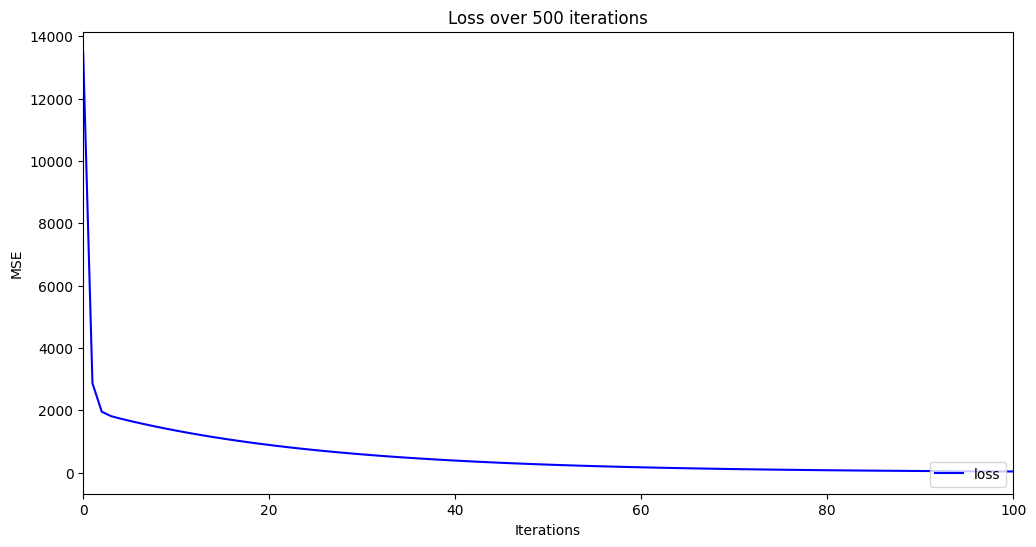

In [59]:
plt.figure(figsize=(12, 6))
plt.plot(GD[3], 'b-', label = 'loss')
# plt.xlim(0,50)
plt.title('Loss over 500 iterations')
plt.legend(loc="lower right")
plt.xlim((0,100))
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.show()

In [60]:
gradients = calc_gradient_5th_poly(
    rand_coeffs,
    hundred_xs,
    ys
)

print(gradients)
print(len(gradients))

(np.float64(-10692851581.997215), np.float64(76023769.91997185), np.float64(-124029079.21269326), np.float64(1580482.1643262731), np.float64(-1499558.0933795976), np.float64(29806.39437765734))
6


(-5, 8, 0, 9, 9, 0)
6
(-5, 8, 0, 9, 9, 0)
6


/tmp/ipykernel_8511/1511627215.py:12: RuntimeWarning: overflow encountered in multiply
  return sum((ys - y_bar) * (ys - y_bar)) / len(ys)
/tmp/ipykernel_8511/2848933283.py:21: RuntimeWarning: overflow encountered in scalar multiply
  a_s.append((x**5) * error)
/tmp/ipykernel_8511/2848933283.py:31: RuntimeWarning: invalid value encountered in scalar add
  gradient_b = (-2 / n) * sum(b_s)
/tmp/ipykernel_8511/2848933283.py:33: RuntimeWarning: invalid value encountered in scalar add
  gradient_d = (-2 / n) * sum(d_s)
/tmp/ipykernel_8511/2848933283.py:35: RuntimeWarning: invalid value encountered in scalar add
  gradient_f = (-2 / n) * sum(f_s)
/tmp/ipykernel_8511/1126668919.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  a_new = coeffs[0] - lr * gradients[0]


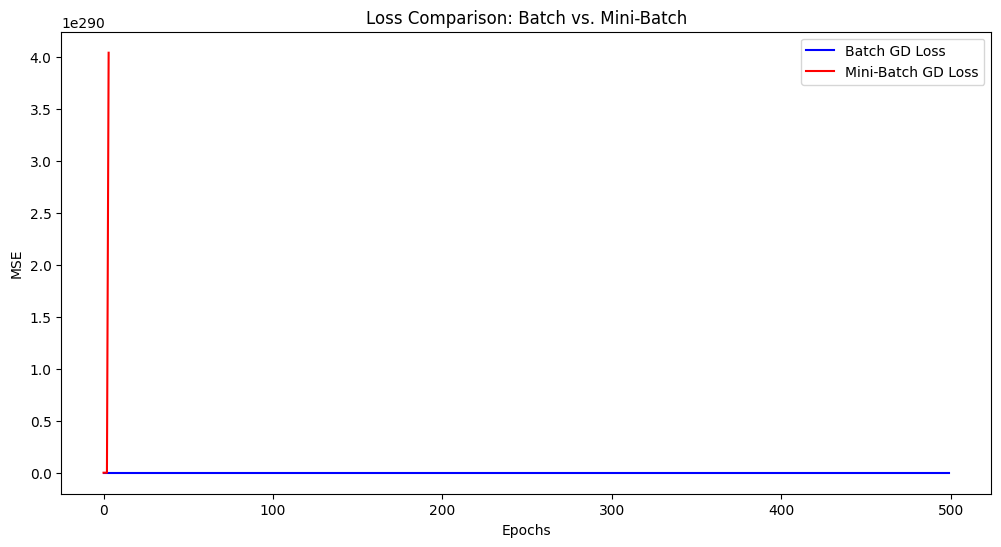

In [61]:
def mini_batch_gradient_descent(epochs, lr, batch_size):
    """
    Perform mini-batch gradient descent.

    Args:
        epochs: number of iterations to perform.
        lr: specified learning rate
        batch_size: number of samples per mini-batch

    Returns: Tuple containing (final loss, final coefficients, list of losses per batch)
    """
    losses = []
    # Start with our initial random coefficients
    coeffs_to_test = rand_coeffs

    # Convert data to numpy arrays for easier slicing
    X_data = np.array(hundred_xs)
    Y_data = np.array(ys)

    print(rand_coeffs)
    print(len(rand_coeffs))

    print(coeffs_to_test)
    print(len(coeffs_to_test))

    for i in range(epochs):
        # Shuffle data at the beginning of each epoch
        # This is crucial for mini-batch GD to work well!
        p = np.random.permutation(len(X_data))
        X_data, Y_data = X_data[p], Y_data[p]

        epoch_loss = []
        # Iterate over mini-batches
        for j in range(0, len(X_data), batch_size):
            # Get the current mini-batch
            X_batch = X_data[j:j+batch_size]
            Y_batch = Y_data[j:j+batch_size]

            # Calculate gradient and update on the mini-batch
            loss, new_coeffs, _ = calc_gradient_5th_poly_for_GD(coeffs_to_test, X_batch, Y_batch, lr)
            coeffs_to_test = new_coeffs
            epoch_loss.append(loss)

        # Average loss for the epoch
        losses.append(np.mean(epoch_loss))

    # Return the final results after all epochs
    final_y_bar = eval_5th_degree(coeffs_to_test, hundred_xs)
    final_loss = loss_mse(ys, final_y_bar)

    return final_loss, coeffs_to_test, losses

# Run Mini-Batch GD
# Note: We can often use fewer epochs and a slightly larger learning rate
MGD = mini_batch_gradient_descent(epochs=500, lr=0.0001, batch_size=16)

# Plotting the loss curves for comparison
plt.figure(figsize=(12, 6))
# We only plot the first 500 losses from Batch GD for a fair comparison
plt.plot(GD[3][:500], 'b-', label = 'Batch GD Loss')
plt.plot(MGD[2], 'r-', label = 'Mini-Batch GD Loss')
plt.title('Loss Comparison: Batch vs. Mini-Batch')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [62]:
GD = gradient_descent(30000, 0.001)


/tmp/ipykernel_8511/1511627215.py:12: RuntimeWarning: overflow encountered in multiply
  return sum((ys - y_bar) * (ys - y_bar)) / len(ys)
/tmp/ipykernel_8511/2848933283.py:21: RuntimeWarning: overflow encountered in scalar multiply
  a_s.append((x**5) * error)
/tmp/ipykernel_8511/2848933283.py:31: RuntimeWarning: invalid value encountered in scalar add
  gradient_b = (-2 / n) * sum(b_s)
/tmp/ipykernel_8511/2848933283.py:33: RuntimeWarning: invalid value encountered in scalar add
  gradient_d = (-2 / n) * sum(d_s)
/tmp/ipykernel_8511/2848933283.py:35: RuntimeWarning: invalid value encountered in scalar add
  gradient_f = (-2 / n) * sum(f_s)
/tmp/ipykernel_8511/1126668919.py:5: RuntimeWarning: invalid value encountered in scalar subtract
  a_new = coeffs[0] - lr * gradients[0]


[np.float64(1.2463597380783951e+23), np.float64(5.9259875126696665e+35), np.float64(2.8176031007510014e+48), np.float64(1.339673298425879e+61), np.float64(6.36968544660188e+73), np.float64(3.028566198663889e+86), np.float64(1.4399789905767902e+99), np.float64(6.846604489666874e+111), np.float64(3.2553247890894666e+124), np.float64(1.5477948957697123e+137), np.float64(7.359232010889024e+149), np.float64(3.499061531867954e+162), np.float64(1.6636833280540982e+175), np.float64(7.91024162003681e+187), np.float64(3.7610476364242265e+200), np.float64(1.7882487037591153e+213), np.float64(8.502507108727992e+225), np.float64(4.0426494917626514e+238), np.float64(1.9221406938281035e+251), np.float64(9.139117438695084e+263), np.float64(4.3453357928714645e+276), np.float64(2.066057612178572e+289), np.float64(9.823392852270827e+301), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf), np.float64(inf)

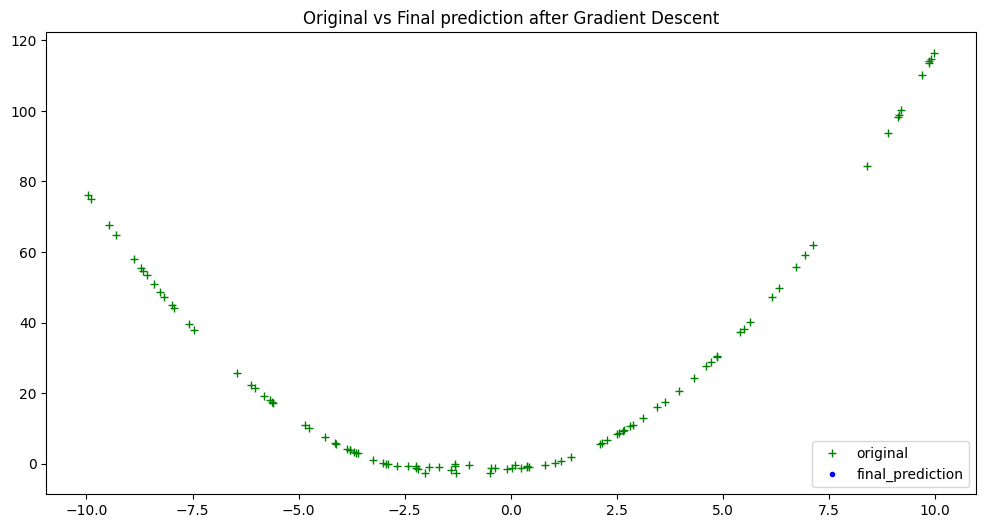

In [63]:
plt.figure(figsize=(12,6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, GD[2], 'b.', label = 'final_prediction')
plt.title('Original vs Final prediction after Gradient Descent')
plt.legend(loc = "lower right")
plt.show()

In [64]:
print(f"Final Coefficients predicted: {GD[1]}")
print(f"Original Coefficients: {coeffs}")

Final Coefficients predicted: (np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan))
Original Coefficients: [1, 2, -3, 4, 5, 6]
